## 🎯 Project Objective

- Understand key health & lifestyle factors linked to heart disease
- Build a logistic regression model to predict heart disease risk
- Generate actionable health insights
- Evaluate model performance with metrics & visualizations

### Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

### Load the dataset

In [2]:
df = pd.read_csv("heart_disease_risk.csv")

### Dataset overview and analysis

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,0,3,121,337,1,0,150,0,5.4,0,3,2,1
1,57,1,3,176,337,0,1,98,0,6.2,0,2,1,1
2,43,0,2,122,295,1,0,143,0,2.2,1,1,2,0
3,71,1,1,156,204,0,0,86,0,1.5,2,2,1,1
4,36,1,3,107,158,0,0,153,0,2.8,0,1,2,1


In [5]:
df.shape

(150, 14)

In [6]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
df['target'].value_counts()

target
1    130
0     20
Name: count, dtype: int64

### Exploratory data analysis

#### Target variable distribution - Countplot

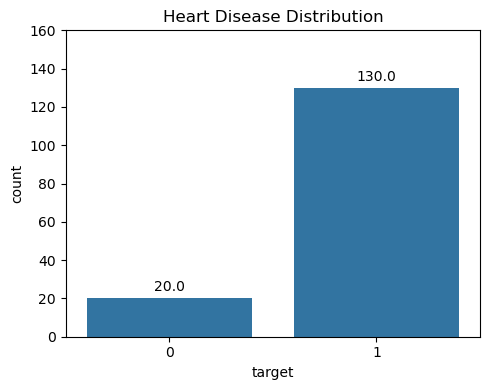

In [20]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.ylim(0, 160) 
# Add counts on bars
for p in ax.patches:
    ax.annotate(format(p.get_height()),
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points')
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\02_logistic_regression_heart_disease_risk\images\heart_disease_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Key insights

Heart disease cases appear higher than non-cases, indicating class imbalance and the need to consider it during modeling.

#### Age distribution

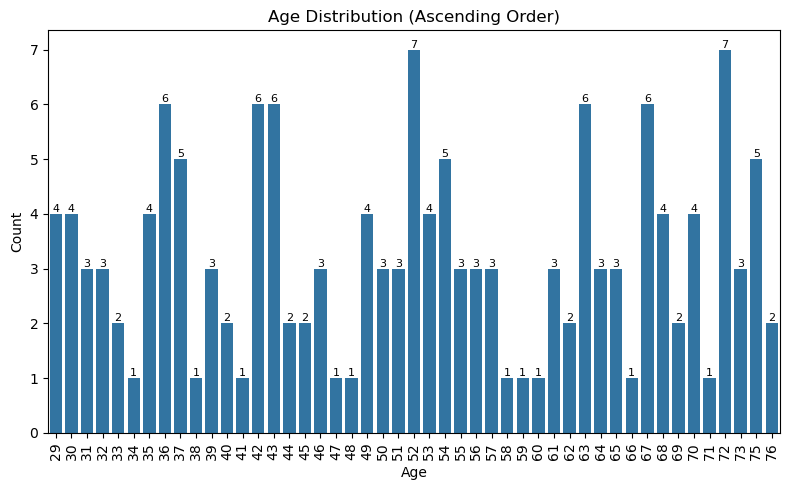

In [21]:
age_counts = df['age'].value_counts().sort_values()  # ascending order

plt.figure(figsize=(8,5))
ax = sns.barplot(x=age_counts.index, y=age_counts.values)

plt.title("Age Distribution (Ascending Order)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=90)

# Add counts on bars
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\02_logistic_regression_heart_disease_risk\images\age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Gender vs heart_disease

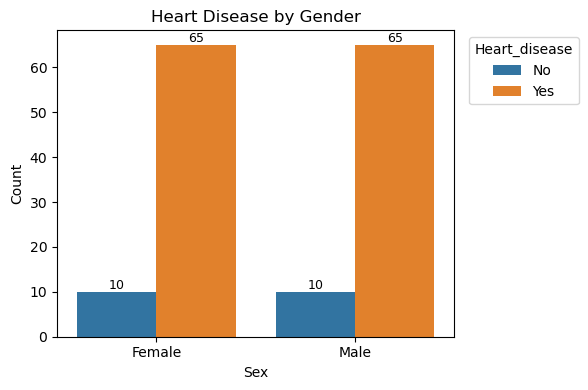

In [26]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='sex', hue='target', data=df)

plt.title("Heart Disease by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks([0,1], ["Female","Male"])

# Rename legend labels
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ["No","Yes"], title="Heart_disease",
           loc='upper left', bbox_to_anchor=(1.02,1))

# Add counts on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(int(p.get_height()),
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\02_logistic_regression_heart_disease_risk\images\gender_vs_heart_disease.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Correlation heatmap

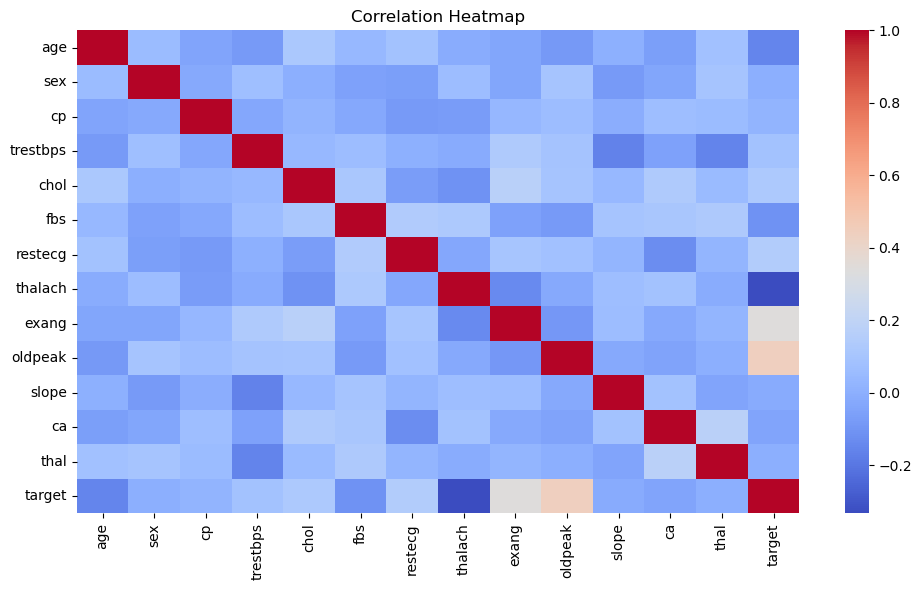

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\02_logistic_regression_heart_disease_risk\images\correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Key insights

- Chest pain (cp), exercise-induced angina (exang), ST-depression (oldpeak), and max heart rate (thalach) show the strongest relationships with target.
- thalach is negatively correlated with heart disease, while oldpeak and exang are positively correlated.
- Most features show low-to-moderate correlation with each other, reducing multicollinearity risk.

### Data preparation and modeling

#### Encode categorical variables if present

In [29]:
df_encoded = pd.get_dummies(df, drop_first=True)

#### Features & Target

In [30]:
X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

#### Train-Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#### Feature Scaling

In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Logistic Regression Model

In [33]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.96      0.96      0.96        26

    accuracy                           0.93        30
   macro avg       0.86      0.86      0.86        30
weighted avg       0.93      0.93      0.93        30



#### Key insights

- Overall model accuracy is 93%, indicating strong performance.
- Class 1 (heart disease) is predicted very well with 96% precision and recall.
- Class 0 (no disease) performs slightly lower at 75% precision and recall, likely due to fewer samples.
- Weighted scores stay high, meaning performance is consistent despite class imbalance.

### Model evaluation

#### Confusion matrix

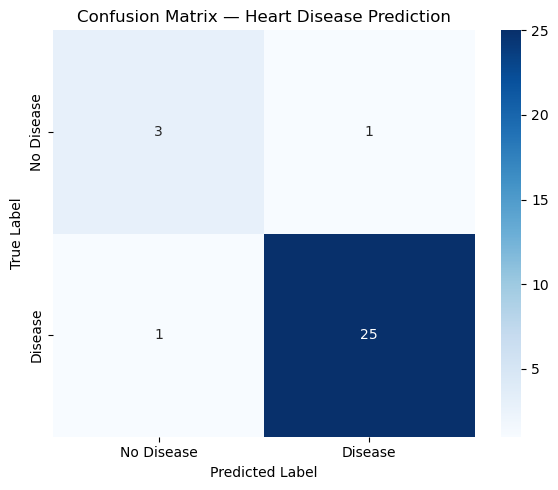

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])

plt.title("Confusion Matrix — Heart Disease Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\02_logistic_regression_heart_disease_risk\images\confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Key insights

Model correctly predicts most disease cases with few false predictions, indicating strong diagnostic performance.

### ROC curve

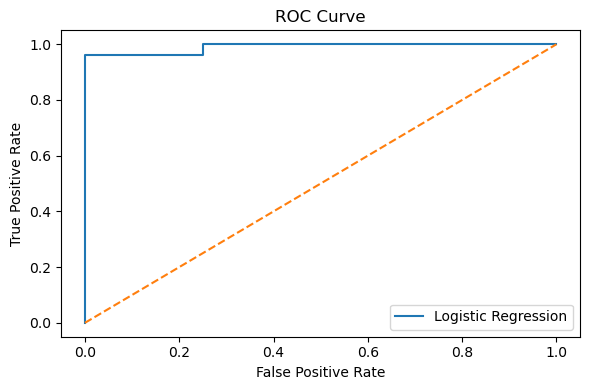


AUC Score: 0.9903846153846154


In [37]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\02_logistic_regression_heart_disease_risk\images\ROC_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

auc = roc_auc_score(y_test, y_prob)
print("\nAUC Score:", auc)

#### Key insights

- The ROC curve is very close to the top-left corner, indicating excellent classification performance.
- The AUC score of 0.99 shows the model almost perfectly separates heart-disease and non-disease cases.
- Very low false-positive and false-negative rates suggest highly reliable predictions.

#### Feature importance


Top Predictors:
     Feature  Importance
9   oldpeak    2.258577
8     exang    1.710448
6   restecg    0.513730
12     thal    0.305589
2        cp    0.185005


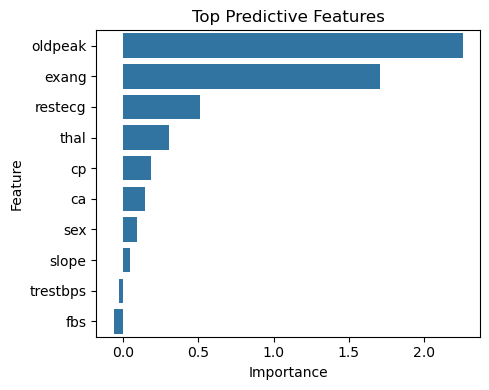

In [39]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
}).sort_values(by="Importance", ascending=False)

print("\nTop Predictors:\n", coeffs.head())

plt.figure(figsize=(5,4))
sns.barplot(data=coeffs.head(10), x="Importance", y="Feature")
plt.title("Top Predictive Features")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\02_logistic_regression_heart_disease_risk\images\feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

## 📌 Key insights and learning summary

Heart Disease Risk Prediction using Logistic Regression

### Logistics Regression performance
- Accuracy: 0.93
- Precision (Heart Disease): 0.96
- Recall (Heart Disease): 0.96
- AUC Score: 0.99

### Model interpretation

- Model predicts heart disease cases very accurately
- False negatives are very low, meaning high-risk patients are rarely missed
- Class imbalance exists but performance remains stable
- ROC curve close to top-left indicates excellent separability

### 🧠 Key Analytical Insights

- **Chest pain type, ST-depression (oldpeak), max heart rate, and exercise-induced angina** are the strongest predictors
- Higher age groups show increased risk
- Male and female patients have similar risk levels in this dataset
- Most independent variables show low correlation, reducing multicollinearity concerns
- Logistic regression provides clear feature influence, helping interpret medical risk drivers

### 🏁 Conclusion

Logistic Regression delivers high-accuracy and interpretable medical risk prediction, making it suitable for healthcare screening applications.

### Key business takeaway:
                                                                                                        
Early detection based on clinical indicators like chest pain, stress-ECG changes, and exercise response can significantly reduce cardiac emergencies and long-term treatment costs through **preventive monitoring and timely intervention**.